# Week 2 Workshop: Relationship Detective in Nepal Tourism

**Topic:** Bivariate relationships, correlation, feature-target relationships, feature-feature relationships, multicollinearity, VIF, and model-readiness decisions.

## Business context
A Nepal-based tourism company offers trekking and cultural packages across Everest, Annapurna, Langtang, Mustang, Manaslu, and Kathmandu-Pokhara routes. The company wants to understand how booking variables relate to one another before using the data for pricing, customer segmentation, and future machine learning models.

## Your final output
Complete the notebook by running the code cells, inserting your interpretations in the answer cells

## Learning outcomes
By the end of this notebook, you should be able to:

1. Explore relationships between two variables using visualizations.
2. Distinguish feature-target relationships from feature-feature relationships.
3. Interpret a correlation matrix and heatmap.
4. Identify possible multicollinearity among predictors.
5. Use VIF conceptually and computationally.
6. Make feature decisions for a machine learning problem using both statistics and domain knowledge.

## Dataset variables

The dataset contains tourism booking records. Important variables include:

- `TotalSpendUSD`: total booking value.
- `SpendPerPersonUSD`: package spend per traveler.
- `TripDays`: itinerary length.
- `MaxAltitudeM`: approximate route altitude.
- `DifficultyScore`: route difficulty from 1 to 5.
- `PermitComplexityScore`: complexity of permits/logistics.
- `Travelers`: group size.
- `LeadDays`: booking lead time.
- `SatisfactionScore`: post-trip satisfaction from 1 to 5.
- `HighValueBooking`: whether the booking value is in the top quartile.

### Key idea for this workshop
 We are asking:

> Which variables move together, and what does that mean for modelling or business decisions?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', 100)

DATA_PATH = 'Week2_Nepal_Tourism_Relationships_Dataset.xlsx'
df = pd.read_excel(DATA_PATH, sheet_name='Tourism_Bookings')

df.head()

,BookingID,BookingMonth,Season,RouteName,Region,MarketSegment,Travelers,LeadDays,TripDays,MaxAltitudeM,DifficultyScore,PermitComplexityScore,AcclimatizationDays,GuideIncluded,AccommodationLevel,BookingChannel,SpendPerPersonUSD,TotalSpendUSD,SatisfactionScore,RebookIntentScore,HighValueBooking,HighSatisfaction
0,NPTRK10001,4,Spring,Annapurna Circuit,Annapurna,International,2,89,15,5416,5,3,4,Yes,Budget,Direct,1431,2804,3.9,4.1,No,No
1,NPTRK10002,3,Spring,Mardi Himal,Annapurna,International,5,85,6,4500,3,2,1,Yes,Standard,Online Platform,850,4196,5.0,5.0,No,Yes
2,NPTRK10003,12,Winter,Ghorepani Poon Hill,Annapurna,Domestic,4,19,6,3210,2,1,1,No,Standard,Online Platform,359,1444,4.6,5.0,No,Yes
3,NPTRK10004,10,Autumn,Mardi Himal,Annapurna,SAARC,4,60,4,4500,3,2,3,Yes,Budget,Direct,340,1309,4.6,4.5,No,Yes
4,NPTRK10005,6,Monsoon,Annapurna Base Camp,Annapurna,International,4,73,10,4130,3,2,2,Yes,Standard,Direct,845,3453,4.9,5.0,No,Yes


In [2]:
# Basic structure of the dataset
print(df.shape)
df.info()

(260, 22)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260 entries, 0 to 259
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   BookingID              260 non-null    object 
 1   BookingMonth           260 non-null    int64  
 2   Season                 260 non-null    object 
 3   RouteName              260 non-null    object 
 4   Region                 260 non-null    object 
 5   MarketSegment          260 non-null    object 
 6   Travelers              260 non-null    int64  
 7   LeadDays               260 non-null    int64  
 8   TripDays               260 non-null    int64  
 9   MaxAltitudeM           260 non-null    int64  
 10  DifficultyScore        260 non-null    int64  
 11  PermitComplexityScore  260 non-null    int64  
 12  AcclimatizationDays    260 non-null    int64  
 13  GuideIncluded          260 non-null    object 
 14  AccommodationLevel     260 non-null    object 
 

In [3]:
# Quick descriptive statistics for numerical variables
num_cols = df.select_dtypes(include='number').columns
round(df[num_cols].describe(), 2)

,BookingMonth,Travelers,LeadDays,TripDays,MaxAltitudeM,DifficultyScore,PermitComplexityScore,AcclimatizationDays,SpendPerPersonUSD,TotalSpendUSD,SatisfactionScore,RebookIntentScore
count,260.00,260.00,260.00,260.00,260.00,260.00,260.00,260.00,260.00,260.00,260.00,260.00
mean,6.78,3.62,70.28,9.27,4119.02,3.25,2.66,1.87,1099.70,3702.22,4.43,4.33
std,3.61,1.88,22.85,3.55,1187.80,1.28,1.36,1.11,683.19,2825.92,0.34,0.46
min,1.00,1.00,18.00,3.00,415.00,1.00,1.00,0.00,166.00,297.00,3.50,3.20
25%,4.00,2.00,54.00,6.00,3840.00,2.00,2.00,1.00,573.50,1718.75,4.20,4.00
50%,6.50,3.00,73.00,9.00,4130.00,3.00,2.00,2.00,878.00,2982.50,4.50,4.40
75%,10.00,5.00,88.25,12.00,5106.00,5.00,4.00,3.00,1520.50,4647.50,4.70,4.70
max,12.00,10.00,118.00,16.00,5416.00,5.00,5.00,4.00,3613.00,20085.00,5.00,5.00


---
# Task 1: Domain intuition before analysis

Before making graphs, use your domain knowledge.

## Question 1
Choose **three pairs of variables** that you expect to be related in Nepal tourism bookings. For each pair, briefly explain the expected relationship.

Example: `TripDays` and `SpendPerPersonUSD` may be positively related because longer itineraries usually cost more.

### Your answer
1.  `MaximumAltitudeM` and `DifficultyScore` may be positive related as more altitude makes more difficult.
2.  `Travellers` and `TotalSpendUSD` may be positevly related as more travellers means more total spend.
4. `GuideIncluded` and `SpendPerPersonUSD` may be positevly related as guide included costs more.

---
# Task 2: Distribution check

 Distribution still matters to explore relationships . Skewed variables and extreme values can affect correlation.

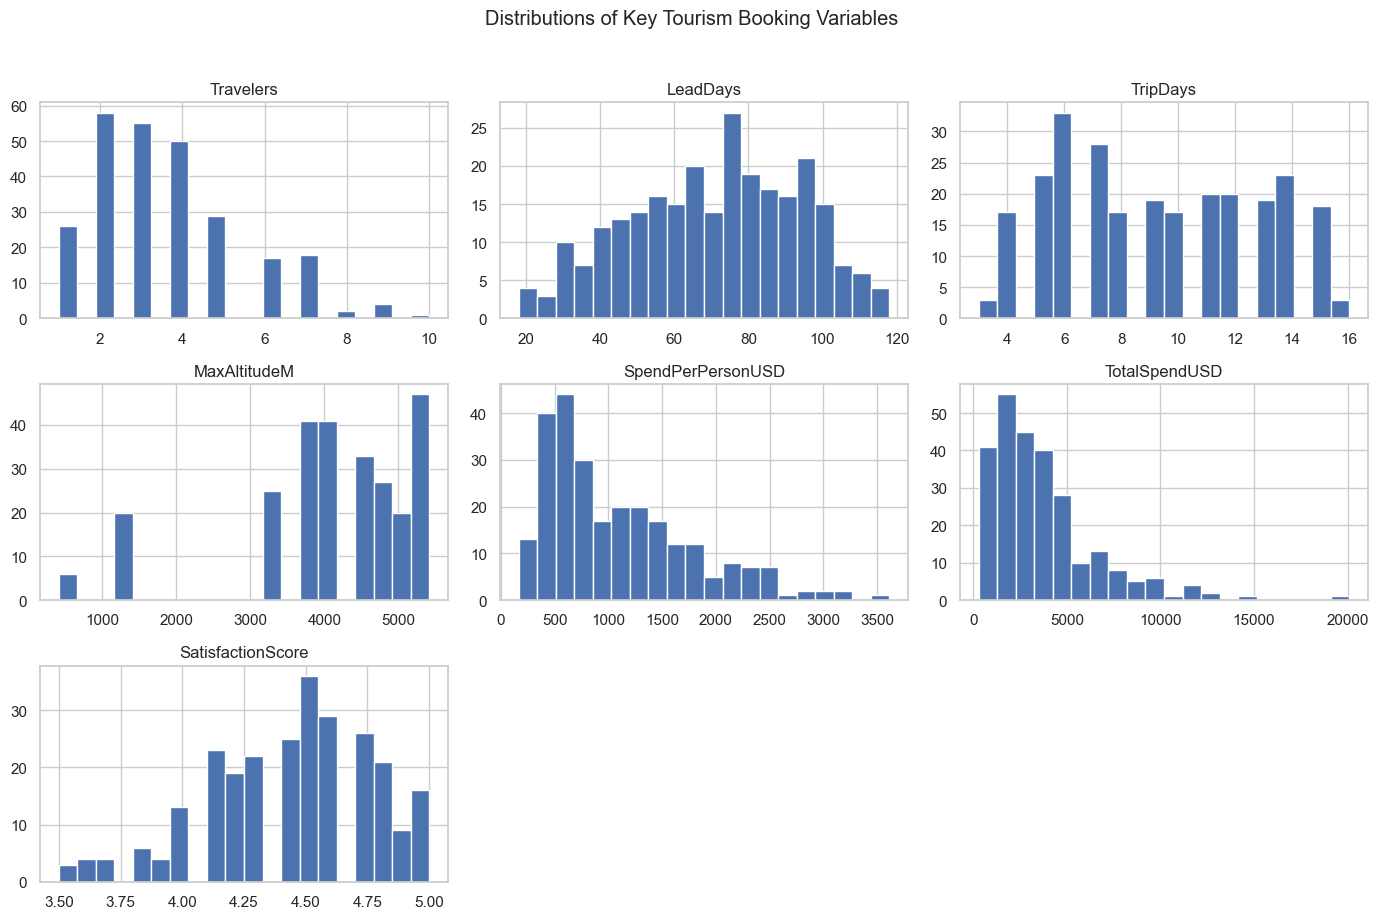

In [4]:
# Histograms of key numerical variables
plot_cols = ['Travelers', 'LeadDays', 'TripDays', 'MaxAltitudeM', 'SpendPerPersonUSD', 'TotalSpendUSD', 'SatisfactionScore']

df[plot_cols].hist(figsize=(14, 9), bins=20)
plt.suptitle('Distributions of Key Tourism Booking Variables', y=1.02)
plt.tight_layout()
plt.show()

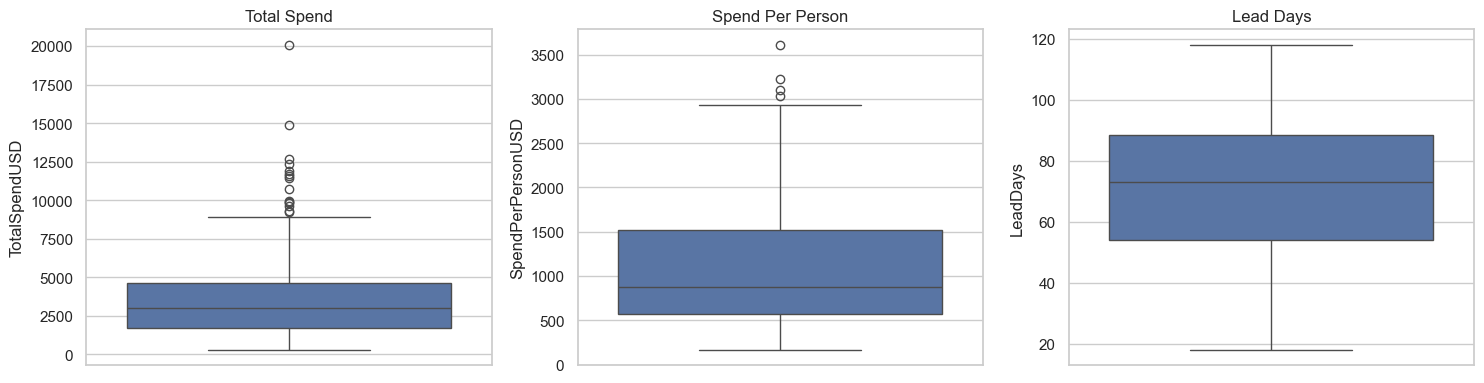

In [5]:
# Box plots for variables likely to have spread or outliers
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.boxplot(y=df['TotalSpendUSD'], ax=axes[0])
axes[0].set_title('Total Spend')
sns.boxplot(y=df['SpendPerPersonUSD'], ax=axes[1])
axes[1].set_title('Spend Per Person')
sns.boxplot(y=df['LeadDays'], ax=axes[2])
axes[2].set_title('Lead Days')
plt.tight_layout()
plt.show()

## Question 2
Based on the histograms and box plots:

- Which variables look most skewed?
- Which variables may influence correlation strongly because of their spread?
- Why should we look at distributions before interpreting relationships?

### Your answer
`TotalSpendUSD` looks more skewed and it may also influence correlation. we should look as the distributions before interpreting as it may affect the staticial methods.


---
# Task 3: Bivariate relationship exploration

In this section, you will explore how two variables behave together.

Look for:

- direction: positive, negative, or no clear trend
- strength: strong, moderate, weak
- shape: linear or nonlinear
- clusters: different groups or route types
- business interpretation

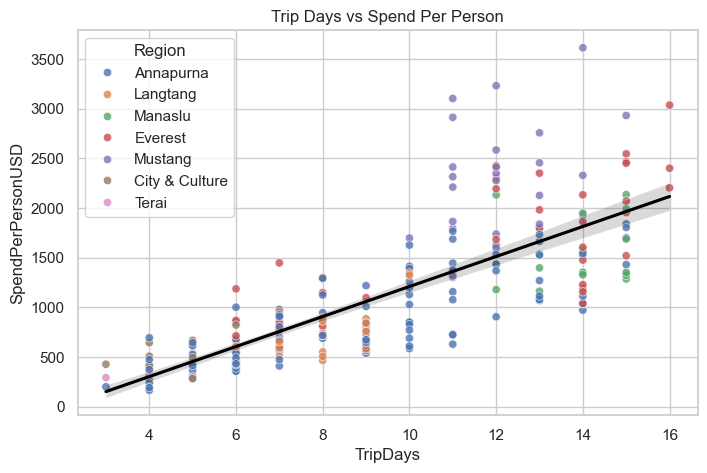

In [6]:
# Relationship 1: Trip length and spend per person
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='TripDays', y='SpendPerPersonUSD', hue='Region', alpha=0.8)
sns.regplot(data=df, x='TripDays', y='SpendPerPersonUSD', scatter=False, color='black')
plt.title('Trip Days vs Spend Per Person')
plt.show()

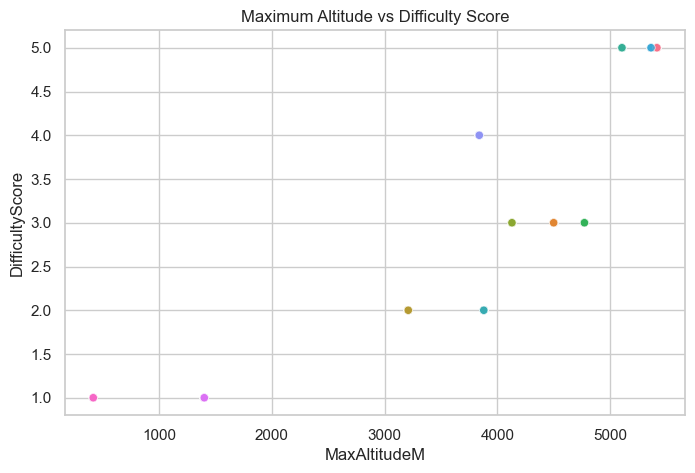

In [7]:
# Relationship 2: Altitude and difficulty
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='MaxAltitudeM', y='DifficultyScore', hue='RouteName', legend=False, alpha=0.8)
plt.title('Maximum Altitude vs Difficulty Score')
plt.show()

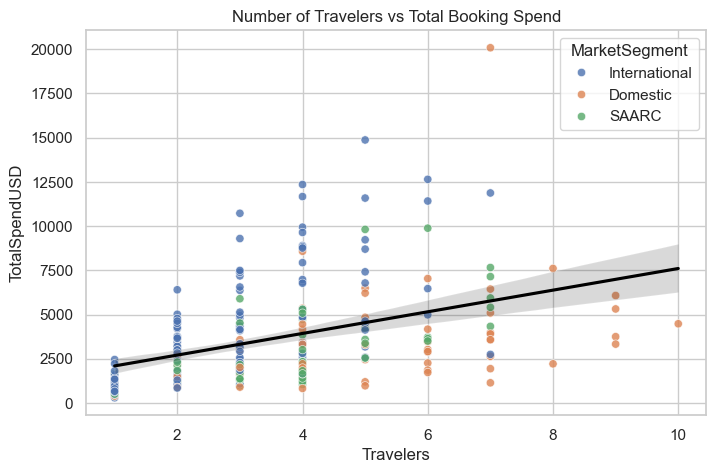

In [8]:
# Relationship 3: Travelers and total spend
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df, x='Travelers', y='TotalSpendUSD', hue='MarketSegment', alpha=0.8)
sns.regplot(data=df, x='Travelers', y='TotalSpendUSD', scatter=False, color='black')
plt.title('Number of Travelers vs Total Booking Spend')
plt.show()

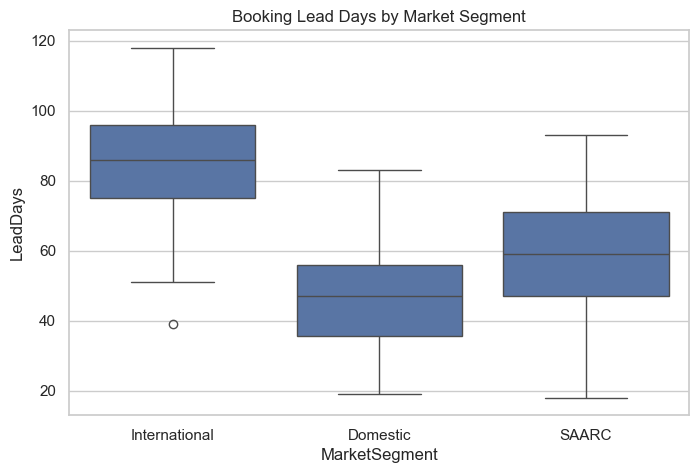

In [9]:
# Relationship 4: Lead days by market segment
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='MarketSegment', y='LeadDays')
plt.title('Booking Lead Days by Market Segment')
plt.show()

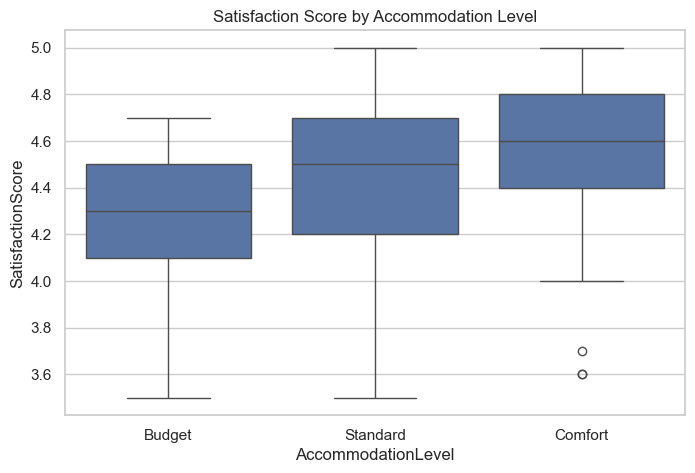

In [10]:
# Relationship 5: Satisfaction by accommodation level
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='AccommodationLevel', y='SatisfactionScore', order=['Budget','Standard','Comfort'])
plt.title('Satisfaction Score by Accommodation Level')
plt.show()

## Question 3
Choose **three charts** from Task 3 and interpret them.

For each selected chart, write:

1. What relationship do you observe?
2. Is the pattern strong, moderate, weak, or unclear?
3. Does the relationship make business sense?
4. Would this relationship be useful for prediction, segmentation, or decision-making?

### Your answer

**Chart 1:**  
`TripDays vs SpendPerPersonUSD`
This pattern is moderate
Yes this relationship make business sense as tourist who stayed for more days spend more money for accomudfation.
yes, it would be useful:
***Prediction***: it may help to predict the `SpendPerPersonUSD` based on trip days.
***Segmentation***: Group the tourists into short, medium and long stayed for the marketing.
***Decision-making***: yes it helps the business to plan on the pricing strategies, packages.
**Chart 2:**  
`Number of Travelers vs Total Booking Spend`
This pattern is moderate
Yes this relationship make business sense as increase in the travellers will cost more.
yes, it would be useful:
***Prediction***: it helps to estimate the total bookings based on the total number of travellers
***Segmentation***: Group the tourists into solo, groups for the marketing.
***Decision-making***: yes it helps to allocate the recources based on the travellers, make the discounts forr the groups.

**Chart 3:**
`Satisfaction Score by Accommodation Level`
This pattern is moderate
Yes this relationship make business sense as higher quality accomudation leads to better sastification score.
yes, it would be useful:
***Prediction***: it helps to estimate customer satisfaction based on accommodation level.
***Segmentation***: group customer by accomudation.
***Decision-making***: Improve lower-rated accommodations, promote higher-quality options to increase customer satisfaction.

---
# Task 4: Correlation matrix and heatmap

Correlation tells us the direction and strength of a **linear** relationship between numerical variables.

Important reminder:

> Correlation does not prove causation.

In [11]:
# Encode simple binary variables for correlation analysis
analysis_df = df.copy()
analysis_df['GuideIncludedBinary'] = analysis_df['GuideIncluded'].map({'Yes': 1, 'No': 0})
analysis_df['HighValueBinary'] = analysis_df['HighValueBooking'].map({'Yes': 1, 'No': 0})
analysis_df['HighSatisfactionBinary'] = analysis_df['HighSatisfaction'].map({'Yes': 1, 'No': 0})

corr_cols = [
    'Travelers', 'LeadDays', 'TripDays', 'MaxAltitudeM', 'DifficultyScore',
    'PermitComplexityScore', 'AcclimatizationDays', 'GuideIncludedBinary',
    'SpendPerPersonUSD', 'TotalSpendUSD', 'SatisfactionScore',
    'RebookIntentScore', 'HighValueBinary', 'HighSatisfactionBinary'
]

corr = analysis_df[corr_cols].corr()
round(corr, 2)

,Travelers,LeadDays,TripDays,MaxAltitudeM,DifficultyScore,PermitComplexityScore,AcclimatizationDays,GuideIncludedBinary,SpendPerPersonUSD,TotalSpendUSD,SatisfactionScore,RebookIntentScore,HighValueBinary,HighSatisfactionBinary
Travelers,1.00,-0.39,-0.13,-0.13,-0.16,-0.13,-0.19,-0.14,-0.23,0.41,-0.01,0.06,0.30,0.00
LeadDays,-0.39,1.00,0.42,0.38,0.47,0.42,0.40,0.15,0.59,0.28,0.07,-0.13,0.21,0.11
TripDays,-0.13,0.42,1.00,0.65,0.88,0.79,0.69,0.21,0.78,0.59,-0.07,-0.16,0.51,-0.05
MaxAltitudeM,-0.13,0.38,0.65,1.00,0.85,0.53,0.84,0.14,0.41,0.29,-0.07,-0.23,0.24,-0.05
DifficultyScore,-0.16,0.47,0.88,0.85,1.00,0.79,0.82,0.19,0.68,0.49,-0.12,-0.27,0.43,-0.09
PermitComplexityScore,-0.13,0.42,0.79,0.53,0.79,1.00,0.55,0.19,0.80,0.60,-0.06,-0.22,0.53,-0.01
AcclimatizationDays,-0.19,0.40,0.69,0.84,0.82,0.55,1.00,0.18,0.46,0.30,-0.06,-0.21,0.24,-0.03
GuideIncludedBinary,-0.14,0.15,0.21,0.14,0.19,0.19,0.18,1.00,0.25,0.12,0.39,0.07,0.08,0.33
SpendPerPersonUSD,-0.23,0.59,0.78,0.41,0.68,0.80,0.46,0.25,1.00,0.71,0.15,-0.12,0.59,0.17
TotalSpendUSD,0.41,0.28,0.59,0.29,0.49,0.60,0.30,0.12,0.71,1.00,0.12,-0.09,0.79,0.14


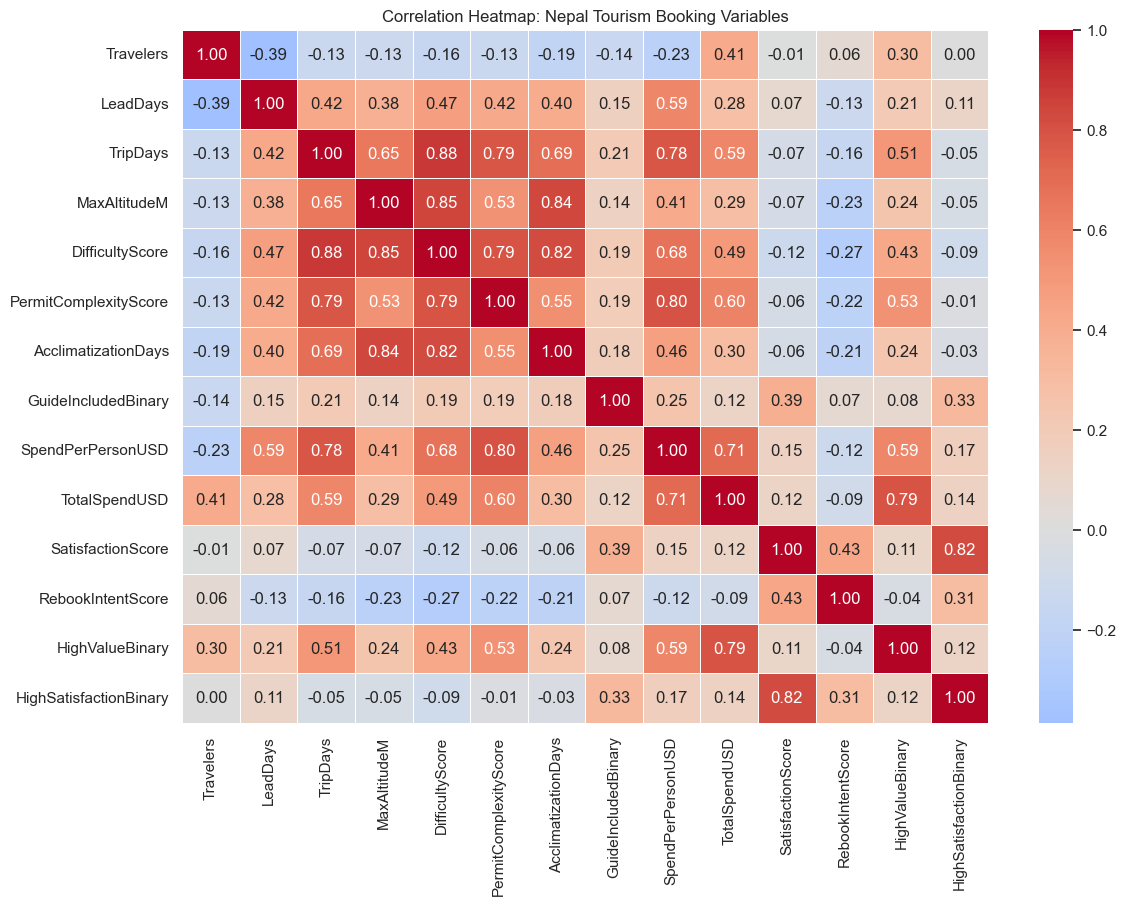

In [12]:
plt.figure(figsize=(13, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=.5)
plt.title('Correlation Heatmap: Nepal Tourism Booking Variables')
plt.show()

## Question 4
Using the correlation matrix or heatmap:

1. Identify **two feature-target relationships** with `TotalSpendUSD` or `HighValueBinary`.
2. Identify **two feature-feature relationships** that may indicate redundancy or multicollinearity.
3. Identify one correlation that is expected from domain knowledge.
4. Identify one correlation that needs caution or deeper interpretation.

### Your answer

1. Feature-target relationships: `TotalSpendUSD` has a strong positive relation with `SpendPerPersonUSD` (0.71) and `TripDays` (0.59). Also `HighValueBinary` is highly related to `TotalSpendUSD` (0.79).

2. Feature-feature relationships: `DifficultyScore` is strongly related to `TripDays` (0.88) and `MaxAltitudeM` (0.85), which might cause redundancy.

3. Expected correlation: `MaxAltitudeM` and `AcclimatizationDays` have high correlation (0.84) because higher altitude treks naturally need more rest days for safety.

4. Correlation needing caution: `DifficultyScore` has a negative correlation with `RebookIntentScore` (-0.27). This suggests that tourists doing harder treks might not want to rebook because it is too tiring, which needs caution before deciding they were unsatisfied.


---
# Task 5: Multicollinearity and VIF

Multicollinearity occurs when predictor variables are strongly related to one another.

This matters because highly related predictors may repeat the same signal and make model interpretation unstable.

In this section, we will use VIF to diagnose feature dependence.

In [13]:


try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    import statsmodels.api as sm
    print('statsmodels is available')
except Exception as e:
    print('statsmodels is not available in this environment:', e)

statsmodels is available


In [14]:
# VIF calculation for selected numerical predictors
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_features = [
    'Travelers', 'LeadDays', 'TripDays', 'MaxAltitudeM', 'DifficultyScore',
    'PermitComplexityScore', 'AcclimatizationDays', 'GuideIncludedBinary'
]

X = analysis_df[vif_features].copy()
X = sm.add_constant(X)

vif_table = pd.DataFrame({
    'Feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})

vif_table = vif_table[vif_table['Feature'] != 'const'].sort_values('VIF', ascending=False)
round(vif_table, 2)

,Feature,VIF
5,DifficultyScore,14.41
3,TripDays,5.49
4,MaxAltitudeM,5.37
7,AcclimatizationDays,4.12
6,PermitComplexityScore,3.41
2,LeadDays,1.49
1,Travelers,1.20
8,GuideIncludedBinary,1.06


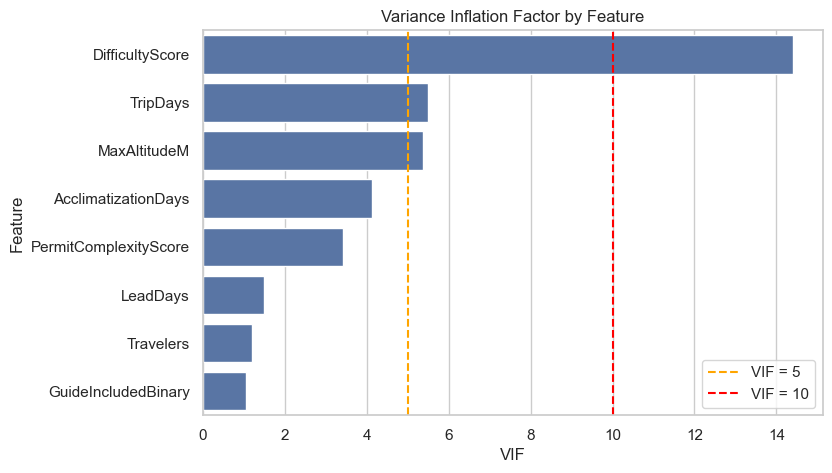

In [15]:
plt.figure(figsize=(8, 5))
sns.barplot(data=vif_table, x='VIF', y='Feature')
plt.axvline(5, color='orange', linestyle='--', label='VIF = 5')
plt.axvline(10, color='red', linestyle='--', label='VIF = 10')
plt.title('Variance Inflation Factor by Feature')
plt.legend()
plt.show()

## Question 5
Interpret the VIF results.

1. Which variables have the highest VIF values?
2. What common tourism concept might these variables be measuring?
3. Which variables would you keep, remove, or combine if the goal were to build a simple and explainable model?
4. Would your answer change if the goal were only prediction accuracy?

### Your answer

1. `DifficultyScore` has the highest VIF of 14.41. `TripDays` (5.49) and `MaxAltitudeM` (5.37) are also high.
2. They are all measuring the overall toughness or physical demand of the trekking route.
3. I would remove `DifficultyScore` because of its high VIF and keep `TripDays` since it is easy to understand and measure.
4. Yes, if we only want accuracy we can keep all features because multicollinearity affects explainability and coefficients but does not hurt predictions.


---
A small model comparison

This section shows how a model can be affected by related features. The goal is not to build the best model. The goal is to see how feature choices change interpretation.

We will predict `SpendPerPersonUSD` using two feature sets:

- **Full feature set:** includes several related route-complexity variables.
- **Reduced feature set:** keeps fewer, more interpretable variables.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

# Full and reduced features
full_features = ['Travelers','LeadDays','TripDays','MaxAltitudeM','DifficultyScore','PermitComplexityScore','AcclimatizationDays','GuideIncludedBinary']
reduced_features = ['Travelers','LeadDays','TripDays','GuideIncludedBinary']

y = analysis_df['SpendPerPersonUSD']

X_full = analysis_df[full_features]
X_reduced = analysis_df[reduced_features]

Xf_train, Xf_test, yf_train, yf_test = train_test_split(X_full, y, test_size=0.25, random_state=42)
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reduced, y, test_size=0.25, random_state=42)

model_full = LinearRegression().fit(Xf_train, yf_train)
model_reduced = LinearRegression().fit(Xr_train, yr_train)

pred_full = model_full.predict(Xf_test)
pred_reduced = model_reduced.predict(Xr_test)

print('Full model R2:', round(r2_score(yf_test, pred_full), 3))
print('Full model MAE:', round(mean_absolute_error(yf_test, pred_full), 2))
print('Reduced model R2:', round(r2_score(yr_test, pred_reduced), 3))
print('Reduced model MAE:', round(mean_absolute_error(yr_test, pred_reduced), 2))

coef_full = pd.DataFrame({'Feature': full_features, 'Coefficient': model_full.coef_}).sort_values('Coefficient', ascending=False)
coef_reduced = pd.DataFrame({'Feature': reduced_features, 'Coefficient': model_reduced.coef_}).sort_values('Coefficient', ascending=False)

print('\nFull model coefficients')
display(coef_full)
print('\nReduced model coefficients')
display(coef_reduced)

Full model R2: 0.776
Full model MAE: 220.26
Reduced model R2: 0.615
Reduced model MAE: 282.6

Full model coefficients


,Feature,Coefficient
5,PermitComplexityScore,221.605479
7,GuideIncludedBinary,181.040812
2,TripDays,109.123541
1,LeadDays,9.757341
0,Travelers,2.254816
3,MaxAltitudeM,-0.052174
6,AcclimatizationDays,-67.289531
4,DifficultyScore,-83.820150



Reduced model coefficients


,Feature,Coefficient
3,GuideIncludedBinary,178.407024
2,TripDays,123.870416
0,Travelers,11.825749
1,LeadDays,10.303642


## Optional reflection
Compare the full and reduced models.

- Did the full model clearly outperform the reduced model?
- Which model is easier to explain to tourism managers?
- If prediction accuracy is similar, which model would you recommend and why?

### Your answer

- Yes, the full model performed better with a higher R2 (0.776 vs 0.615) and a lower MAE (220.26 vs 282.6).
- The reduced model is easier to explain because it only uses 4 simple features like trip days and group size, which managers can easily understand.
- If accuracy was similar, I would recommend the reduced model because it is simpler, easier to explain, and does not have multicollinearity issues.


---
# Final task: Model-readiness memo

Write a short memo of **250 to 350 words** to the tourism company.

Your memo should include:

1. Three important relationships discovered in the data.
2. One or two variables that may be redundant because of multicollinearity.
3. One recommendation for feature selection or feature engineering.
4. One warning about interpreting correlation.
5. Whether the dataset is ready for a first modelling experiment.

## Your memo:

Dear Tourism Company Team,

We have completed the bivariate analysis on our Nepal tourism dataset. Here are the main findings to guide our upcoming machine learning model development.

First, we found three important relationships in the data. There is a strong positive correlation (0.78) between TripDays and SpendPerPersonUSD, meaning longer trips lead to higher package spend per traveler. There is also a strong correlation (0.84) between MaxAltitudeM and AcclimatizationDays, which makes sense as higher treks require more safety rest days. Lastly, the number of Travelers is positively correlated (0.41) with TotalSpendUSD because larger groups spend more overall.

Second, our analysis shows that some variables are redundant. DifficultyScore has a very high Variance Inflation Factor (VIF) of 14.41, and MaxAltitudeM has a VIF of 5.37. These variables are highly correlated with each other and with TripDays. This multicollinearity can make a regression model's coefficients unstable and hard to interpret.

To solve this, we recommend dropping DifficultyScore and keeping TripDays and MaxAltitudeM, which are easier to explain to managers. Alternatively, we could combine these into a single 'Route Complexity' score.

We must warn the team that correlation does not prove causation. For example, guide inclusion is positively correlated with higher spending, but simply including guides in budget packages will not automatically cause those travelers to spend more money.

Overall, the dataset is clean and ready for our first modeling experiment. We recommend starting with a reduced feature set of Travelers, LeadDays, TripDays, and GuideIncluded to avoid multicollinearity while maintaining good explainability.

Sincerely,
Data Science Team
